In [1]:
!pip install cartopy scikit-learn seaborn matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 111.5 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import time
import os
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import seaborn as sns

# Ensure 300 dpi for all plots
plt.rcParams['figure.dpi'] = 300

results_path = 'cvae_results'
os.makedirs(results_path, exist_ok=True)

# ==========================================
# 1. BEST PARAMETERS
# ==========================================
best_params = {'batch_size': 256, 'beta': 0.5, 'epochs': 80, 'hidden_dim': 256, 'latent_dim': 8, 'lr': 0.0005}

print("Best Parameters:", best_params)

# ==========================================
# 2. LOAD & CLEAN DATA
# ==========================================
print("\nLoading and cleaning data...")
data_path = 'NGA_sub_screened_Flatfile.xlsx'
df = pd.read_excel(data_path, sheet_name='Sheet1')

raw_target_cols = [
    'PGA_g',
    'T0pt010S', 'T0pt020S', 'T0pt030S', 'T0pt050S', 'T0pt080S',
    'T0pt100S', 'T0pt150S', 'T0pt200S', 'T0pt250S', 'T0pt300S',
    'T0pt400S', 'T0pt500S', 'T0pt700S', 'T1pt000S', 'T1pt500S',
    'T2pt000S', 'T3pt000S', 'T4pt000S', 'T5pt000S', 'T6pt000S',
]

for col in raw_target_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

for col in raw_target_cols:
    df = df[(df[col] > 0) & (df[col] != -999)].copy()

df = df[(df['Hypocenter_Latitude_deg'] != -999) & (df['Hypocenter_Longitude_deg'] != -999)].copy()

for col in raw_target_cols:
    df[f'log_{col}'] = np.log10(df[col])

target_cols = [f'log_{col}' for col in raw_target_cols]

df['Rjb_km'] = pd.to_numeric(df['Rjb_km'], errors='coerce')
df['Vs30_Selected_for_Analysis_m_s'] = pd.to_numeric(df['Vs30_Selected_for_Analysis_m_s'], errors='coerce')
df = df.dropna(subset=['Rjb_km', 'Vs30_Selected_for_Analysis_m_s'])

df['log_Rjb'] = np.log10(df['Rjb_km'].clip(lower=0.1))
df['log_Vs30'] = np.log10(df['Vs30_Selected_for_Analysis_m_s'])

fault_dummies = pd.get_dummies(df['Fault_Type'], prefix='FaultType').astype(int)
df = pd.concat([df, fault_dummies], axis=1)
fault_type_cols = fault_dummies.columns.tolist()

node_feature_cols = ['Rjb_km', 'log_Rjb', 'log_Vs30']
global_feature_cols = ['Earthquake_Magnitude', 'Hypocenter_Depth_km', 'Intra_Inter_Flag'] + fault_type_cols
cond_cols = node_feature_cols + global_feature_cols

df = df.dropna(subset=cond_cols + target_cols)

X_cond = df[cond_cols].values
Y_target = df[target_cols].values

print(f"Final Data Shape - Features: {X_cond.shape}, Targets: {Y_target.shape}")

# ==========================================
# 3. PREPARE DATA FOR PYTORCH
# ==========================================
scaler_X = StandardScaler()
scaler_Y = StandardScaler()

X_scaled = scaler_X.fit_transform(X_cond)
Y_scaled = scaler_Y.fit_transform(Y_target)

X_train, X_val, Y_train, Y_val = train_test_split(X_scaled, Y_scaled, test_size=0.2, random_state=42)

X_train_t = torch.tensor(X_train, dtype=torch.float32)
Y_train_t = torch.tensor(Y_train, dtype=torch.float32)
X_val_t = torch.tensor(X_val, dtype=torch.float32)
Y_val_t = torch.tensor(Y_val, dtype=torch.float32)

train_dataset = TensorDataset(X_train_t, Y_train_t)
val_dataset = TensorDataset(X_val_t, Y_val_t)

train_loader = DataLoader(train_dataset, batch_size=best_params['batch_size'], shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=best_params['batch_size'], shuffle=False)

# ==========================================
# 4. DEFINE ENHANCED CVAE & PHYSICS LOSS
# ==========================================
class EnhancedCVAE(nn.Module):
    def __init__(self, input_dim, cond_dim, latent_dim, hidden_dim=128):
        super(EnhancedCVAE, self).__init__()
        self.enc1 = nn.Linear(input_dim + cond_dim, hidden_dim)
        self.enc2 = nn.Linear(hidden_dim, hidden_dim)
        self.fc_mu = nn.Linear(hidden_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)

        self.dec1 = nn.Linear(latent_dim + cond_dim, hidden_dim)
        self.dec2 = nn.Linear(hidden_dim + cond_dim, hidden_dim)
        self.dec3 = nn.Linear(hidden_dim + cond_dim, hidden_dim)
        self.out = nn.Linear(hidden_dim, input_dim)
        self.dropout = nn.Dropout(0.2)

    def encode(self, x, c):
        inputs = torch.cat([x, c], dim=1)
        h1 = F.relu(self.enc1(inputs))
        h2 = F.relu(self.enc2(h1))
        return self.fc_mu(h2), self.fc_logvar(h2)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z, c):
        h1 = torch.cat([z, c], dim=1)
        h1 = F.relu(self.dec1(h1))
        h2 = torch.cat([h1, c], dim=1)
        h2 = F.relu(self.dropout(self.dec2(h2)))
        h3 = torch.cat([h2, c], dim=1)
        h3 = F.relu(self.dec3(h3))
        return self.out(h3)

    def forward(self, x, c):
        mu, logvar = self.encode(x, c)
        z = self.reparameterize(mu, logvar)
        reconstructed_x = self.decode(z, c)
        return reconstructed_x, mu, logvar

def physics_informed_cvae_loss(recon_x, x, mu, logvar, beta, model, c_batch, latent_dim):
    recon_loss = F.mse_loss(recon_x, x, reduction='mean')
    kl_loss = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())

    physics_loss = 0.0
    with torch.no_grad():
        z = torch.randn(c_batch.size(0), latent_dim).to(c_batch.device)

    c_higher_mag = c_batch.clone()
    # Magnitude is at index 3 in cond_cols ('Earthquake_Magnitude')
    c_higher_mag[:, 3] += 0.5

    pred_base = model.decode(z, c_batch)
    pred_high = model.decode(z, c_higher_mag)

    violation = F.relu(pred_base - pred_high)
    physics_loss = torch.mean(violation)

    lambda_phys = 10.0
    total_loss = recon_loss + (beta * kl_loss) + (lambda_phys * physics_loss)

    return total_loss, recon_loss, kl_loss, physics_loss

# ==========================================
# 5. TRAIN MODEL WITH BEST PARAMS
# ==========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\n--- Model Training on {device} ---")

target_dim = Y_train.shape[1]
cond_dim = X_train.shape[1]

best_model = EnhancedCVAE(
    input_dim=target_dim,
    cond_dim=cond_dim,
    latent_dim=best_params['latent_dim'],
    hidden_dim=best_params['hidden_dim']
).to(device)

optimizer = optim.Adam(best_model.parameters(), lr=best_params['lr'], weight_decay=1e-5)
epochs = best_params['epochs']
max_beta = best_params['beta']

history = {'epoch': [], 'train_loss': [], 'test_loss': []}

for epoch in range(epochs):
    best_model.train()
    current_beta = min(max_beta, (epoch / (epochs * 0.5)) * max_beta)

    train_mse_loss = 0
    for batch_c, batch_y in train_loader:
        batch_c, batch_y = batch_c.to(device), batch_y.to(device)
        optimizer.zero_grad()
        recon_batch, mu, logvar = best_model(batch_y, batch_c)
        loss, recon_loss, _, _ = physics_informed_cvae_loss(
            recon_batch, batch_y, mu, logvar, current_beta, best_model, batch_c, best_params['latent_dim']
        )
        loss.backward()
        torch.nn.utils.clip_grad_norm_(best_model.parameters(), max_norm=1.0)
        optimizer.step()
        train_mse_loss += recon_loss.item() * len(batch_y)

    train_mse_loss /= len(train_loader.dataset)

    # Evaluation
    best_model.eval()
    val_mse_loss = 0
    with torch.no_grad():
        for batch_c, batch_y in val_loader:
            batch_c, batch_y = batch_c.to(device), batch_y.to(device)
            recon_batch, mu, logvar = best_model(batch_y, batch_c)
            loss, recon_loss, _, _ = physics_informed_cvae_loss(
                recon_batch, batch_y, mu, logvar, max_beta, best_model, batch_c, best_params['latent_dim']
            )
            val_mse_loss += recon_loss.item() * len(batch_y)

    val_mse_loss /= len(val_loader.dataset)

    history['epoch'].append(epoch + 1)
    history['train_loss'].append(train_mse_loss)
    history['test_loss'].append(val_mse_loss)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs} | Train MSE: {train_mse_loss:.4f} | Val MSE: {val_mse_loss:.4f}")

# ==========================================
# 6. YOUR PREVIOUS CVAE PLOTS
# ==========================================
print("\nGenerating Figure 1: Distribution of Data on Map...")
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.scatter(df['Station_Longitude_deg'], df['Station_Latitude_deg'], color='blue', s=5, alpha=0.5, label='Stations', transform=ccrs.PlateCarree())
ax.scatter(df['Hypocenter_Longitude_deg'], df['Hypocenter_Latitude_deg'], color='red', marker='x', s=10, alpha=0.5, label='Earthquakes', transform=ccrs.PlateCarree())
plt.title('Distribution of Seismic Stations and Hypocenters')
plt.legend(loc='lower right')
plt.savefig(f'{results_path}/cvae_distribution_map.png', bbox_inches='tight')
plt.show()

print("Generating Figure 2: Statistics Plot (Distributions)...")
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
sns.histplot(df['Earthquake_Magnitude'], kde=True, ax=axes[0,0], color='skyblue').set_title('Magnitude Distribution')
sns.histplot(df['Hypocenter_Depth_km'], kde=True, ax=axes[0,1], color='salmon').set_title('Depth (km) Distribution')
sns.histplot(df['Rjb_km'], kde=True, ax=axes[1,0], color='lightgreen').set_title('Joyner-Boore Distance (km)')
sns.histplot(df['Vs30_Selected_for_Analysis_m_s'], kde=True, ax=axes[1,1], color='gold').set_title('Vs30 (m/s) Distribution')
plt.tight_layout()
plt.savefig(f'{results_path}/cvae_statistics_plot.png', bbox_inches='tight')
plt.show()


# ==========================================
# 7. FRIEND'S GNN PLOTS (ADAPTED FOR CVAE)
# ==========================================
print("\nGenerating Figure 3: TRAINING VS TEST LOSS CURVE — Overfitting Monitor")
fig, ax = plt.subplots(figsize=(10, 6))
epochs_list = history['epoch']
ax.plot(epochs_list, history['train_loss'], 'b-', linewidth=2, label='Training Loss (MSE)')
ax.plot(epochs_list, history['test_loss'], 'r-', linewidth=2, label='Test Loss (MSE)')

final_train = history['train_loss'][-1]
final_test = history['test_loss'][-1]
ax.scatter([epochs_list[-1]], [final_train], color='blue', s=80, zorder=5, marker='o')
ax.scatter([epochs_list[-1]], [final_test], color='red', s=80, zorder=5, marker='o')

gap = final_test - final_train
ax.annotate(f'Gap: {gap:.4f}\n(test - train)',
            xy=(epochs_list[-1], (final_train + final_test) / 2),
            xytext=(epochs_list[-1] - len(epochs_list)*0.3, max(history['test_loss'])*0.85),
            fontsize=10, color='purple',
            arrowprops=dict(arrowstyle='->', color='purple', lw=1.5))

ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Reconstruction MSE Loss', fontsize=12)
ax.set_title(f'Training vs Test Loss — {len(epochs_list)} Epochs (CVAE)\n'
             f'Overfitting check: final test-train gap = {gap:.4f}',
             fontsize=13, fontweight='bold')
ax.legend(loc='upper right', fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{results_path}/cvae_trainval_vs_test_loss.png', dpi=150, bbox_inches='tight')
plt.show()

# ==========================================
# 8. PARAMETRIC STUDY — SETUP
# ==========================================
period_map = {}
spectral_target_cols = []
spectral_periods = []

for col in target_cols:
    if col == 'log_PGA_g':
        period_map[col] = 0.01
        spectral_target_cols.append(col)
        spectral_periods.append(0.01)
    elif col.startswith('log_T'):
        period_str = col[5:-1]
        period_str = period_str.replace('pt', '.')
        try:
            period = float(period_str)
            period_map[col] = period
            spectral_target_cols.append(col)
            spectral_periods.append(period)
        except ValueError:
            pass

sorted_indices = np.argsort(spectral_periods)
spectral_target_cols = [spectral_target_cols[i] for i in sorted_indices]
spectral_periods = [spectral_periods[i] for i in sorted_indices]
spectral_target_indices = [target_cols.index(col) for col in spectral_target_cols]

all_feature_cols = node_feature_cols + global_feature_cols
median_rjb_km = df['Rjb_km'].median()
median_log_rjb = df['log_Rjb'].median()
median_log_vs30 = df['log_Vs30'].median()
median_mag = df['Earthquake_Magnitude'].median()
median_depth = df['Hypocenter_Depth_km'].median()
median_intra_inter = float(df['Intra_Inter_Flag'].mode().iloc[0])
fault_type_mode = int(df['Fault_Type'].mode().iloc[0])
fault_type_cols_list = [c for c in all_feature_cols if c.startswith('FaultType')]
median_fault_vec = [1.0 if c == f'FaultType_{fault_type_mode}' else 0.0 for c in fault_type_cols_list]

def predict_cvae_spectrum(model, rjb_km, log_rjb, log_vs30, eq_mag, hypo_depth, intra_inter, fault_vec):
    """
    Predict response spectrum using CVAE deterministic decoding (mean of latent space).
    """
    raw_row = [rjb_km, log_rjb, log_vs30, eq_mag, hypo_depth, intra_inter] + list(fault_vec)
    raw_features = np.array([raw_row])

    scaled_features = scaler_X.transform(raw_features)
    c = torch.tensor(scaled_features, dtype=torch.float32).to(device)

    # Use zero vector (mean of normal prior) to get deterministic mean spectrum prediction
    z = torch.zeros(1, best_params['latent_dim']).to(device)

    model.eval()
    with torch.no_grad():
        pred_scaled = model.decode(z, c).cpu().numpy()

    pred_unscaled = scaler_Y.inverse_transform(pred_scaled)[0]
    log_psa = pred_unscaled[spectral_target_indices]
    psa_g = 10 ** log_psa

    return np.array(spectral_periods), psa_g

# ==========================================
# 9. PARAMETRIC STUDY — MAGNITUDE
# ==========================================
print("\nGenerating Figure 4: PARAMETRIC STUDY — MAGNITUDE")
magnitudes = [4.0, 5.0, 6.0, 7.0, 7.5]
mag_colors = ['red', 'green', 'blue', 'black', 'magenta']

fig, ax = plt.subplots(1, 1, figsize=(8, 6))
for mag, color in zip(magnitudes, mag_colors):
    periods, psa_values = predict_cvae_spectrum(
        best_model, rjb_km=median_rjb_km, log_rjb=median_log_rjb,
        log_vs30=median_log_vs30, eq_mag=mag, hypo_depth=median_depth,
        intra_inter=median_intra_inter, fault_vec=median_fault_vec
    )
    ax.loglog(periods, psa_values, color=color, linewidth=2, label=f'$M_w$ {mag}')

ax.set_xlabel('Period (s)', fontsize=12)
ax.set_ylabel('PSA (g)', fontsize=12)
ax.set_title('Spectral Acceleration vs Period — Varying Magnitude\n(CVAE Predictions)', fontsize=13, fontweight='bold')
ax.legend(loc='lower left', fontsize=10)
ax.grid(True, which='both', alpha=0.3)
ax.set_xlim([1e-2, 1e1])
plt.tight_layout()
plt.savefig(f'{results_path}/cvae_parametric_magnitude.png', dpi=150, bbox_inches='tight')
plt.show()

# ==========================================
# 10. PARAMETRIC STUDY — DISTANCE
# ==========================================
print("Generating Figure 5: PARAMETRIC STUDY — DISTANCE")
distances_km = [10, 22.36, 50, 111.80, 250]
dist_colors = ['red', 'yellow', 'green', 'blue', 'magenta']
dist_labels = [f'$R_{{jb}}$ {d}km' for d in distances_km]

fig, ax = plt.subplots(1, 1, figsize=(8, 6))
for dist_km, color, label in zip(distances_km, dist_colors, dist_labels):
    rjb = dist_km
    log_rjb = np.log10(max(dist_km, 0.1))
    periods, psa_values = predict_cvae_spectrum(
        best_model, rjb_km=rjb, log_rjb=log_rjb,
        log_vs30=median_log_vs30, eq_mag=median_mag, hypo_depth=median_depth,
        intra_inter=median_intra_inter, fault_vec=median_fault_vec
    )
    ax.loglog(periods, psa_values, color=color, linewidth=2, label=label)

ax.set_xlabel('Period (s)', fontsize=12)
ax.set_ylabel('PSA (g)', fontsize=12)
ax.set_title('Spectral Acceleration vs Period — Varying Rupture Distance\n(CVAE Predictions)', fontsize=13, fontweight='bold')
ax.legend(loc='lower left', fontsize=9)
ax.grid(True, which='both', alpha=0.3)
ax.set_xlim([1e-2, 1e1])
plt.tight_layout()
plt.savefig(f'{results_path}/cvae_parametric_distance.png', dpi=150, bbox_inches='tight')
plt.show()

# ==========================================
# 11. PARAMETRIC STUDY — Vs30
# ==========================================
print("Generating Figure 6: PARAMETRIC STUDY — Vs30")
vs30_values_ms = [150, 225, 525, 1070, 1500]
vs30_colors = ['red', 'orange', 'green', 'blue', 'purple']
vs30_labels = [f'Vs30 {v} m/s' for v in vs30_values_ms]

fig, ax = plt.subplots(1, 1, figsize=(8, 6))
for vs30_ms, color, label in zip(vs30_values_ms, vs30_colors, vs30_labels):
    log_vs30 = np.log10(vs30_ms)
    periods, psa_values = predict_cvae_spectrum(
        best_model, rjb_km=median_rjb_km, log_rjb=median_log_rjb,
        log_vs30=log_vs30, eq_mag=median_mag, hypo_depth=median_depth,
        intra_inter=median_intra_inter, fault_vec=median_fault_vec
    )
    ax.loglog(periods, psa_values, color=color, linewidth=2, label=label)

ax.set_xlabel('Period (s)', fontsize=12)
ax.set_ylabel('PSA (g)', fontsize=12)
ax.set_title('Spectral Acceleration vs Period — Varying Vs30\n(CVAE Predictions)', fontsize=13, fontweight='bold')
ax.legend(loc='lower left', fontsize=9)
ax.grid(True, which='both', alpha=0.3)
ax.set_xlim([1e-2, 1e1])
plt.tight_layout()
plt.savefig(f'{results_path}/cvae_parametric_vs30.png', dpi=150, bbox_inches='tight')
plt.show()

# ==========================================
# 12. PARAMETRIC STUDY — PSA vs DISTANCE GRID
# ==========================================
print("Generating Figure 7: PSA vs DISTANCE GRID (Magnitude x Vs30)...")
row_periods = [0.01, 0.1, 0.5, 2.0]
row_labels = ['T = 0.01 s', 'T = 0.1 s', 'T = 0.5 s', 'T = 2.0 s']

col_vs30 = [200, 500, 900]
col_labels = [r'$V_{s30}$ < 360 m/s', r'360 <= $V_{s30}$ < 700 m/s', r'$V_{s30}$ >= 700 m/s']

magnitudes = [5.0, 5.5, 6.0, 6.5, 7.0]
mag_colors = ['#1f77b4', '#2ca02c', '#ff7f0e', '#d62728', '#8b0000']
mag_labels = [f'$M_w$ {m}' for m in magnitudes]

distances = np.logspace(np.log10(10), np.log10(500), 30)

period_indices = []
for p in row_periods:
    closest_idx = min(range(len(spectral_periods)), key=lambda i: abs(spectral_periods[i] - p))
    period_indices.append(closest_idx)

grid_data = {}
for ri, period in enumerate(row_periods):
    grid_data[ri] = {}
    for ci, vs30_ms in enumerate(col_vs30):
        grid_data[ri][ci] = {}
        log_vs30 = np.log10(vs30_ms)
        for mi, mag in enumerate(magnitudes):
            psa_at_period = []
            for dist in distances:
                log_rjb = np.log10(max(dist, 0.1))
                _, psa_spectrum = predict_cvae_spectrum(
                    best_model, rjb_km=dist, log_rjb=log_rjb,
                    log_vs30=log_vs30, eq_mag=mag, hypo_depth=median_depth,
                    intra_inter=median_intra_inter, fault_vec=median_fault_vec
                )
                psa_at_period.append(psa_spectrum[period_indices[ri]])
            grid_data[ri][ci][mi] = np.array(psa_at_period)

fig, axes = plt.subplots(4, 3, figsize=(18, 20), sharex=True)
for ri in range(4):
    for ci in range(3):
        ax = axes[ri, ci]
        for mi, (mag, color, label) in enumerate(zip(magnitudes, mag_colors, mag_labels)):
            ax.loglog(distances, grid_data[ri][ci][mi], color=color, linewidth=1.8, label=label)

        ax.set_xlim([10, 500])
        ax.grid(True, which='both', alpha=0.3)
        ax.tick_params(labelsize=9)

        if ri == 0:
            ax.set_title(col_labels[ci], fontsize=13, fontweight='bold', pad=10)
        if ci == 0:
            ax.set_ylabel(f'{row_labels[ri]}\nPSA (g)', fontsize=11)
        else:
            ax.set_ylabel('')
        if ri == 3:
            ax.set_xlabel('Joyner-Boore Distance $R_{jb}$ (km)', fontsize=11)

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=5, fontsize=12,
           frameon=True, fancybox=True, shadow=True, bbox_to_anchor=(0.5, -0.02))

fig.suptitle(
    'PSA estimates w.r.t. Joyner-Boore distance for different\n'
    'combinations of $M_w$ and $V_{s30}$\n(CVAE Predictions)',
    fontsize=15, fontweight='bold', y=1.02
)

plt.tight_layout()
plt.subplots_adjust(bottom=0.06)
plt.savefig(f'{results_path}/cvae_parametric_psa_vs_distance_grid.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\nAll plots successfully generated and saved to '{results_path}' directory!")

Best Parameters: {'batch_size': 256, 'beta': 0.5, 'epochs': 80, 'hidden_dim': 256, 'latent_dim': 8, 'lr': 0.0005}

Loading and cleaning data...
Final Data Shape - Features: (28199, 12), Targets: (28199, 21)

--- Model Training on cuda ---
Epoch 10/80 | Train MSE: 0.0409 | Val MSE: 0.0400 | LR: 0.0005
Epoch 20/80 | Train MSE: 0.0523 | Val MSE: 0.0508 | LR: 0.00025
Epoch 30/80 | Train MSE: 0.0659 | Val MSE: 0.0648 | LR: 0.000125
Epoch 40/80 | Train MSE: 0.0784 | Val MSE: 0.0769 | LR: 6.25e-05
Epoch 50/80 | Train MSE: 0.0805 | Val MSE: 0.0792 | LR: 3.125e-05
Epoch 60/80 | Train MSE: 0.0804 | Val MSE: 0.0792 | LR: 1.5625e-05
Epoch 70/80 | Train MSE: 0.0806 | Val MSE: 0.0805 | LR: 1.5625e-05
Epoch 80/80 | Train MSE: 0.0805 | Val MSE: 0.0786 | LR: 7.8125e-06

Generating Figure 1: Distribution of Data on Map...


/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


Generating Figure 2: Statistics Plot (Distributions)...

Generating Figure 3: TRAINING VS TEST LOSS CURVE

Generating Figure 4: PARAMETRIC STUDY — MAGNITUDE
Generating Figure 5: PARAMETRIC STUDY — DISTANCE
Generating Figure 6: PARAMETRIC STUDY — Vs30
Generating Figure 7: PSA vs DISTANCE GRID (Magnitude x Vs30)...

All plots successfully generated and saved to 'cvae_results' directory!


Overall R2 (uniform average): 0.8266
Overall R2 (variance weighted): 0.8254

Per-target metrics:
  Target       R2      MAE     RMSE
   PGA_g 0.827239 0.279324 0.359605
T0pt010S 0.826954 0.279489 0.360064
T0pt020S 0.826185 0.280696 0.361503
T0pt030S 0.823173 0.284203 0.366056
T0pt050S 0.812767 0.298046 0.383257
T0pt080S 0.794403 0.322601 0.413837
T0pt100S 0.789813 0.330403 0.423895
T0pt150S 0.794786 0.326609 0.420594
T0pt200S 0.804701 0.314668 0.406715
T0pt250S 0.813755 0.302650 0.391085
T0pt300S 0.823634 0.291734 0.376487
T0pt400S 0.832281 0.278519 0.359075
T0pt500S 0.836402 0.270281 0.346930
T0pt700S 0.834411 0.266892 0.340259
T1pt000S 0.828876 0.265272 0.338103
T1pt500S 0.823970 0.268011 0.339361
T2pt000S 0.823759 0.270854 0.340578
T3pt000S 0.837351 0.264493 0.332930
T4pt000S 0.854148 0.252613 0.319497
T5pt000S 0.869205 0.240079 0.304569
T6pt000S 0.880417 0.232024 0.294868


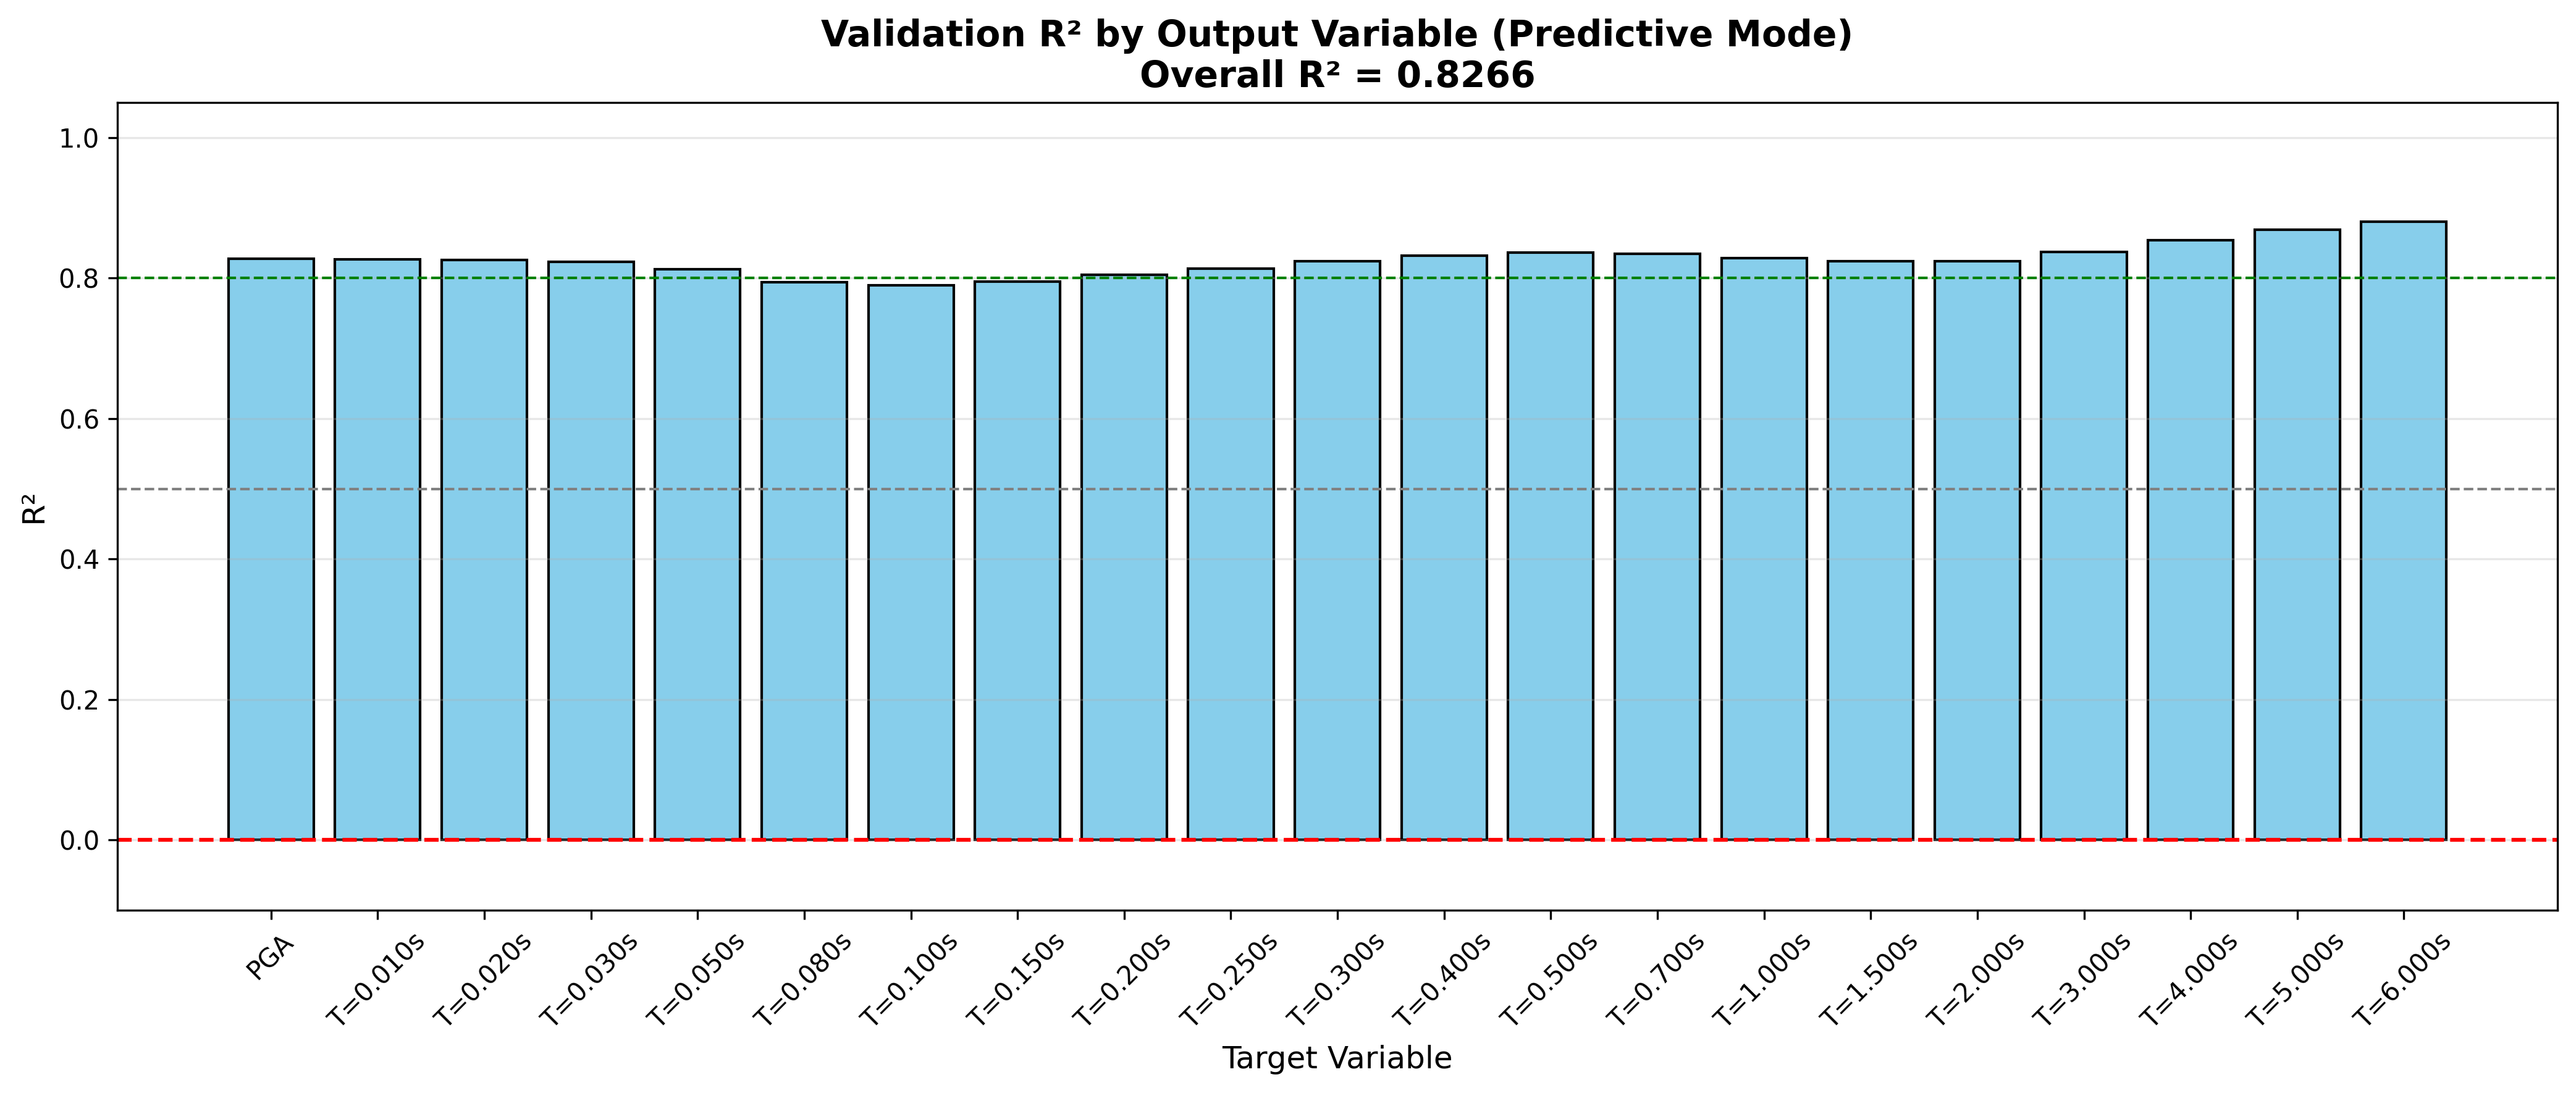


Saved metrics to: cvae_results/cvae_validation_metrics.csv
Saved plot to: cvae_results/cvae_validation_r2_plot.png
Saved true/pred table to: cvae_results/cvae_validation_true_pred.csv


In [3]:
# ==========================================
# 13. R2 / ERROR METRICS + PLOT ON VALIDATION SET
# ==========================================
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import torch

best_model.eval()

y_true_list = []
y_pred_list = []

with torch.no_grad():
    for batch_c, batch_y in val_loader:
        batch_c = batch_c.to(device)
        batch_y = batch_y.to(device)

        # ---------------------------------------------------------
        # CORRECTED PREDICTION LOGIC (NO LEAKAGE)
        # We DO NOT use the encoder. We sample z from the prior (mean=0)
        # to generate a deterministic prediction based purely on C.
        # ---------------------------------------------------------
        z = torch.zeros(batch_c.size(0), best_params['latent_dim']).to(device)
        recon_batch = best_model.decode(z, batch_c)

        y_true_list.append(batch_y.cpu().numpy())
        y_pred_list.append(recon_batch.cpu().numpy())

y_true_scaled = np.vstack(y_true_list)
y_pred_scaled = np.vstack(y_pred_list)

y_true = scaler_Y.inverse_transform(y_true_scaled)
y_pred = scaler_Y.inverse_transform(y_pred_scaled)

overall_r2 = r2_score(y_true, y_pred, multioutput='uniform_average')
overall_r2_var = r2_score(y_true, y_pred, multioutput='variance_weighted')

metrics = []
for i, col in enumerate(raw_target_cols):
    y_t = y_true[:, i]
    y_p = y_pred[:, i]

    r2 = r2_score(y_t, y_p)
    mae = mean_absolute_error(y_t, y_p)
    rmse = np.sqrt(mean_squared_error(y_t, y_p))

    metrics.append({
        "Target": col,
        "R2": r2,
        "MAE": mae,
        "RMSE": rmse
    })

metrics_df = pd.DataFrame(metrics)

print(f"Overall R2 (uniform average): {overall_r2:.4f}")
print(f"Overall R2 (variance weighted): {overall_r2_var:.4f}")
print("\nPer-target metrics:")
print(metrics_df.to_string(index=False))

metrics_df.to_csv(f"{results_path}/cvae_validation_metrics.csv", index=False)

# Nice labels for plotting
plot_labels = []
for col in raw_target_cols:
    if col == "PGA_g":
        plot_labels.append("PGA")
    else:
        p = col.replace("T", "").replace("pt", ".").replace("S", "")
        plot_labels.append(f"T={p}s")

# R2 plot
fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(plot_labels, metrics_df["R2"].values, color='skyblue', edgecolor='black')
ax.axhline(0, linestyle="--", linewidth=1.5, color="red")
ax.axhline(0.5, linestyle="--", linewidth=1, color="gray")
ax.axhline(0.8, linestyle="--", linewidth=1, color="green")
ax.set_ylim([-0.1, 1.05])
ax.set_ylabel("R²", fontsize=12)
ax.set_xlabel("Target Variable", fontsize=12)
ax.set_title(f"Validation R² by Output Variable (Predictive Mode)\nOverall R² = {overall_r2:.4f}", fontsize=14, fontweight='bold')
ax.tick_params(axis="x", rotation=45)
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(f"{results_path}/cvae_validation_r2_plot.png", dpi=300, bbox_inches="tight")
plt.show()

# Optional: save true vs predicted for later use
pred_df = pd.DataFrame(y_pred, columns=[f"pred_{c}" for c in raw_target_cols])
true_df = pd.DataFrame(y_true, columns=[f"true_{c}" for c in raw_target_cols])
out_df = pd.concat([true_df, pred_df], axis=1)
out_df.to_csv(f"{results_path}/cvae_validation_true_pred.csv", index=False)

print(f"\nSaved metrics to: {results_path}/cvae_validation_metrics.csv")
print(f"Saved plot to: {results_path}/cvae_validation_r2_plot.png")
print(f"Saved true/pred table to: {results_path}/cvae_validation_true_pred.csv")